# Multiclass Classification with Spark Batch Trainer

This notebook compares **XGBoost**, **CatBoost**, and **LightGBM** on a seven-class obesity dataset. It demonstrates the complete multiclass workflow with the current package architecture and public API.

## Learning objectives

- inspect and validate a multiclass dataset;
- encode the target without leaking information from validation or test;
- create reproducible stratified splits;
- configure all three backends for multiclass objectives;
- compare class-level errors and probability quality; and
- interpret confidence without treating confidence as calibration.

> **Terminology:** this is multiclass classification—one target and one class per observation—not multilabel classification.

## Phase 1 — Environment and reproducibility

Resolve the repository root explicitly so the notebook behaves the same from the project root and the `notebooks/` directory.

In [24]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """Return the nearest parent containing pyproject.toml."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate pyproject.toml from the current directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_PATH = PROJECT_ROOT / "src"
for import_path in (PROJECT_ROOT, SRC_PATH):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer


In [25]:
import warnings
import pandas as pd
import seaborn as sns
from IPython.display import display
from pyspark.sql import SparkSession

from utils import (
    load_dataset,
    preprocess_splits,
    stratified_split_dataset,
    plot_multiclass_confusion_matrices,
    get_dataset_path,
    plot_class_distribution,
)

from spark_batch_trainer import CatBoostTrainer
from spark_batch_trainer import XGBoostTrainer
from spark_batch_trainer import LightGBMTrainer



warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
TARGET_COLUMN = "NObeyesdad"

## Phase 2 — Load and understand the dataset

Validate the target and basic schema before encoding labels. Class frequency matters because overall accuracy can hide weak performance on smaller classes.

In [26]:
dataset_path = get_dataset_path("data/multiclass_dataset")

print("Loading dataset...")
print("Dataset path:", dataset_path)
dataset = load_dataset(dataset_path)

assert TARGET_COLUMN in dataset.columns, f"Missing target column: {TARGET_COLUMN}"
assert dataset[TARGET_COLUMN].nunique() > 2, "A multiclass target was expected."
assert not dataset.columns.duplicated().any(), "Duplicate column names detected."

quality_summary = pd.DataFrame(
    {
        "rows": [len(dataset)],
        "features": [dataset.shape[1] - 1],
        "classes": [dataset[TARGET_COLUMN].nunique()],
        "missing_values": [int(dataset.isna().sum().sum())],
        "duplicate_rows": [int(dataset.duplicated().sum())],
    }
)
#display(quality_summary)
display(dataset.head())
print(f"row count: {dataset.shape[0]}, features: {dataset.shape[1] - 1}, classes: {dataset[TARGET_COLUMN].nunique()}")

Loading dataset...
Dataset path: /Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer/data/multiclass_dataset/ObesityDataset.csv


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


row count: 2111, features: 16, classes: 7


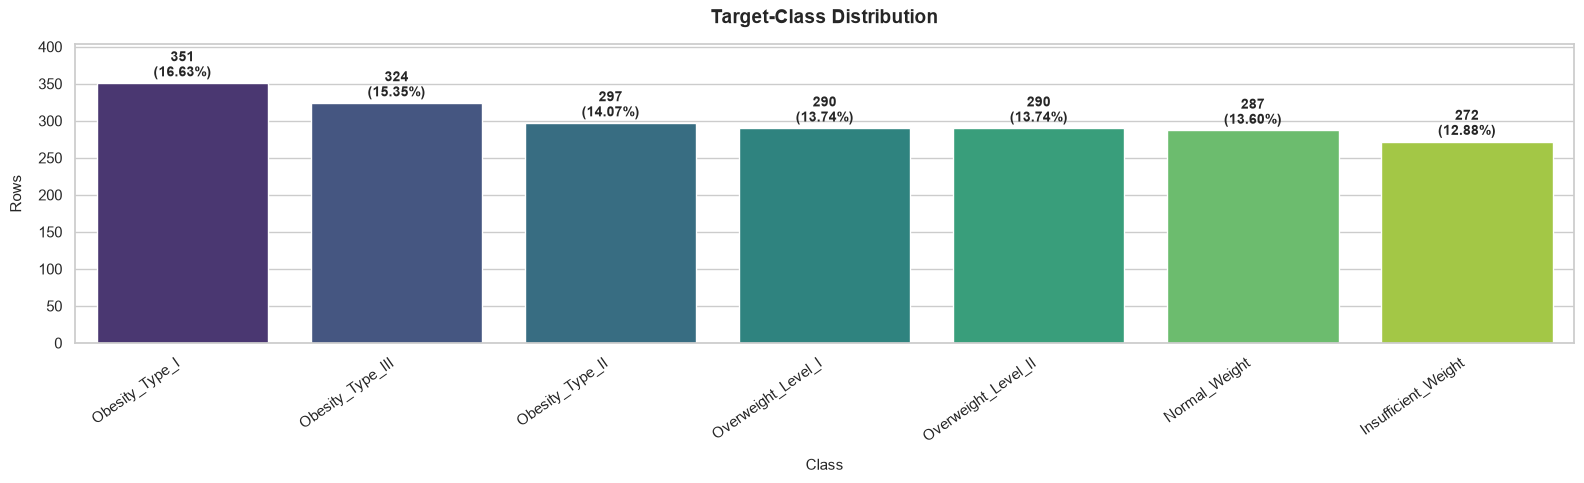

In [27]:
dist_df = plot_class_distribution(dataset, TARGET_COLUMN, figsize=(16, 5))

### Interpretation checkpoint

Review whether every class has enough observations for all three splits. If one class is rare, prefer balanced accuracy and per-class recall over overall accuracy alone.

## Phase 3 — Stratified splitting and target encoding

Split first, then fit the label encoder on the training target only. Transform validation and test with the same mapping so class identifiers remain stable.

In [28]:
train_df, validation_df, test_df = stratified_split_dataset(
    dataset,
    target_column=TARGET_COLUMN,
    train_ratio=0.70,
    valid_ratio=0.15,
    test_ratio=0.15,
    random_state=RANDOM_STATE,
)

splits, label_encoder = preprocess_splits(
    train_df, validation_df, test_df,
    target_column=TARGET_COLUMN,
    y_dtype="int",
    auto_encode_target=True,
)
X_train, y_train = splits.X_train, splits.y_train
X_valid, y_valid = splits.X_valid, splits.y_valid
X_test, y_test = splits.X_test, splits.y_test

CLASS_NAMES = label_encoder.classes_.tolist()
NUMBER_OF_CLASSES = len(CLASS_NAMES)
CLASS_IDS = list(range(NUMBER_OF_CLASSES))

mapping = pd.DataFrame({"class_id": CLASS_IDS, "class_name": CLASS_NAMES})
display(mapping)

,class_id,class_name
0,0,Insufficient_Weight
1,1,Normal_Weight
2,2,Obesity_Type_I
3,3,Obesity_Type_II
4,4,Obesity_Type_III
5,5,Overweight_Level_I
6,6,Overweight_Level_II


In [29]:
split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(frame),
            "classes": frame[TARGET_COLUMN].nunique(),
        }
        for name, frame in (
            ("train", train_df),
            ("validation", validation_df),
            ("test", test_df),
        )
    ]
)
assert split_summary["classes"].eq(NUMBER_OF_CLASSES).all()
display(split_summary)

,split,rows,classes
0,train,1477,7
1,validation,317,7
2,test,317,7


## Phase 4 — Start Spark and create trainer inputs

The trainer receives Spark DataFrames. The untouched test set remains in pandas for final native-model evaluation.

In [30]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("SparkBatchTrainerMulticlassGuide")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

spark_train_df = spark.createDataFrame(
    pd.concat([X_train, y_train.rename(TARGET_COLUMN)], axis=1)
)
spark_validation_df = spark.createDataFrame(
    pd.concat([X_valid, y_valid.rename(TARGET_COLUMN)], axis=1)
)

print(f"Spark version: {spark.version}")
print(f"Training rows: {spark_train_df.count():,}")
print(f"Validation rows: {spark_validation_df.count():,}")

Spark version: 4.1.2


26/08/25 09:54:53 ERROR Executor: Exception in task 0.0 in stage 68.0 (TID 2397)
org.apache.spark.api.python.PythonException: Traceback (most recent call last):
  File "/Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer/.venv/lib/python3.14/site-packages/pyspark/python/lib/pyspark.zip/pyspark/worker.py", line 3301, in main
    split_index = read_int(infile)
  File "/Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer/.venv/lib/python3.14/site-packages/pyspark/python/lib/pyspark.zip/pyspark/serializers.py", line 595, in read_int
    length = stream.read(4)
KeyboardInterrupt

	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.handlePythonException(PythonRunner.scala:645)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:1029)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:1014)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:596)
	at org.apache.spark.In

Py4JJavaError: An error occurred while calling o585.count.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 1 in stage 68.0 failed 1 times, most recent failure: Lost task 1.0 in stage 68.0 (TID 2398) (172.20.10.2 executor driver): org.apache.spark.api.python.PythonException: Traceback (most recent call last):
  File "/Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer/.venv/lib/python3.14/site-packages/pyspark/python/lib/pyspark.zip/pyspark/worker.py", line 3301, in main
    split_index = read_int(infile)
  File "/Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer/.venv/lib/python3.14/site-packages/pyspark/python/lib/pyspark.zip/pyspark/serializers.py", line 595, in read_int
    length = stream.read(4)
KeyboardInterrupt

	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.handlePythonException(PythonRunner.scala:645)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:1029)
	at org.apache.spark.api.py

## Phase 5 — Shared controls and evaluation helpers

Multiclass log loss is minimized. Balanced accuracy is included in the final comparison to give every class equal importance.

In [ ]:
TRAINING_CONFIG = {
    "num_batches": 5,
    "max_patience": 3,
    "metric_mode": "min",
    "min_delta": 1e-4,
    "use_sample_weight": False,
    "show_learning_curve": False,
}

LEARNING_RATE_CONFIG = {
    "initial_lr": 0.05,2
    "decay_rate": 0.95,
    "min_lr": 0.001,
}

In [ ]:
def summarize_history(trainer) -> pd.DataFrame:
    """Return the last train and validation metric recorded per batch."""
    history = trainer.get_training_history()
    return pd.DataFrame(
        {
            "batch": history.batch_numbers,
            "train_metric": [values[-1] for values in history.train_scores],
            "validation_metric": [
                values[-1] for values in history.validation_scores
            ],
        }
    )

## Phase 6 — Train XGBoost

`multi:softprob` produces class probabilities, which are required for multiclass log loss and confidence analysis.

Importing XGBoostTrainer...
XGBoostTrainer instantiated successfully


[0]	validation_0-mlogloss:1.86254	validation_1-mlogloss:1.87825
[1]	validation_0-mlogloss:1.79045	validation_1-mlogloss:1.81878
[2]	validation_0-mlogloss:1.71826	validation_1-mlogloss:1.75792
[3]	validation_0-mlogloss:1.65413	validation_1-mlogloss:1.70523
[4]	validation_0-mlogloss:1.59455	validation_1-mlogloss:1.65512
[5]	validation_0-mlogloss:1.53407	validation_1-mlogloss:1.60465
[6]	validation_0-mlogloss:1.47355	validation_1-mlogloss:1.55565
[7]	validation_0-mlogloss:1.42543	validation_1-mlogloss:1.51542
[8]	validation_0-mlogloss:1.37523	validation_1-mlogloss:1.47238
[9]	validation_0-mlogloss:1.32943	validation_1-mlogloss:1.43538
[10]	validation_0-mlogloss:1.28291	validation_1-mlogloss:1.39696
[11]	validation_0-mlogloss:1.24274	validation_1-mlogloss:1.36460
[12]	validation_0-mlogloss:1.20201	validation_1-mlogloss:1.33279
[13]	validation_0-mlogloss:1.16504	validation_1-mlogloss:1.30204
[14]	validation_0-mlogloss:1.12933	validation_1-mlogloss:1.27435
[15]	validation_0-mlogloss:1.09491	

[0]	validation_0-mlogloss:0.43715	validation_1-mlogloss:0.49836
[1]	validation_0-mlogloss:0.42748	validation_1-mlogloss:0.49395
[2]	validation_0-mlogloss:0.41819	validation_1-mlogloss:0.48899
[3]	validation_0-mlogloss:0.40910	validation_1-mlogloss:0.48481
[4]	validation_0-mlogloss:0.40070	validation_1-mlogloss:0.48223
[5]	validation_0-mlogloss:0.39339	validation_1-mlogloss:0.47905
[6]	validation_0-mlogloss:0.38608	validation_1-mlogloss:0.47670
[7]	validation_0-mlogloss:0.37753	validation_1-mlogloss:0.47230
[8]	validation_0-mlogloss:0.36962	validation_1-mlogloss:0.46940
[9]	validation_0-mlogloss:0.36210	validation_1-mlogloss:0.46528
[10]	validation_0-mlogloss:0.35524	validation_1-mlogloss:0.46210
[11]	validation_0-mlogloss:0.34842	validation_1-mlogloss:0.45838
[12]	validation_0-mlogloss:0.34143	validation_1-mlogloss:0.45444
[13]	validation_0-mlogloss:0.33490	validation_1-mlogloss:0.45232
[14]	validation_0-mlogloss:0.32858	validation_1-mlogloss:0.44991
[15]	validation_0-mlogloss:0.32251	

[0]	validation_0-mlogloss:0.31567	validation_1-mlogloss:0.35100
[1]	validation_0-mlogloss:0.30959	validation_1-mlogloss:0.34961


[2]	validation_0-mlogloss:0.30402	validation_1-mlogloss:0.34872
[3]	validation_0-mlogloss:0.29981	validation_1-mlogloss:0.34712
[4]	validation_0-mlogloss:0.29467	validation_1-mlogloss:0.34681
[5]	validation_0-mlogloss:0.28944	validation_1-mlogloss:0.34531
[6]	validation_0-mlogloss:0.28467	validation_1-mlogloss:0.34358
[7]	validation_0-mlogloss:0.28017	validation_1-mlogloss:0.34139
[8]	validation_0-mlogloss:0.27559	validation_1-mlogloss:0.34021
[9]	validation_0-mlogloss:0.27099	validation_1-mlogloss:0.33952
[10]	validation_0-mlogloss:0.26673	validation_1-mlogloss:0.33868
[11]	validation_0-mlogloss:0.26274	validation_1-mlogloss:0.33757
[12]	validation_0-mlogloss:0.25913	validation_1-mlogloss:0.33633
[13]	validation_0-mlogloss:0.25563	validation_1-mlogloss:0.33545
[14]	validation_0-mlogloss:0.25158	validation_1-mlogloss:0.33451
[15]	validation_0-mlogloss:0.24733	validation_1-mlogloss:0.33367
[16]	validation_0-mlogloss:0.24362	validation_1-mlogloss:0.33253
[17]	validation_0-mlogloss:0.2395

[0]	validation_0-mlogloss:0.28006	validation_1-mlogloss:0.29661
[1]	validation_0-mlogloss:0.27574	validation_1-mlogloss:0.29526
[2]	validation_0-mlogloss:0.27153	validation_1-mlogloss:0.29370
[3]	validation_0-mlogloss:0.26774	validation_1-mlogloss:0.29181
[4]	validation_0-mlogloss:0.26286	validation_1-mlogloss:0.28941
[5]	validation_0-mlogloss:0.25839	validation_1-mlogloss:0.28796
[6]	validation_0-mlogloss:0.25477	validation_1-mlogloss:0.28616
[7]	validation_0-mlogloss:0.25106	validation_1-mlogloss:0.28457
[8]	validation_0-mlogloss:0.24669	validation_1-mlogloss:0.28349
[9]	validation_0-mlogloss:0.24284	validation_1-mlogloss:0.28158
[10]	validation_0-mlogloss:0.23880	validation_1-mlogloss:0.28037
[11]	validation_0-mlogloss:0.23605	validation_1-mlogloss:0.27952
[12]	validation_0-mlogloss:0.23240	validation_1-mlogloss:0.27830
[13]	validation_0-mlogloss:0.22893	validation_1-mlogloss:0.27631
[14]	validation_0-mlogloss:0.22639	validation_1-mlogloss:0.27520
[15]	validation_0-mlogloss:0.22367	

[0]	validation_0-mlogloss:0.17632	validation_1-mlogloss:0.23797
[1]	validation_0-mlogloss:0.17355	validation_1-mlogloss:0.23741
[2]	validation_0-mlogloss:0.17076	validation_1-mlogloss:0.23613
[3]	validation_0-mlogloss:0.16803	validation_1-mlogloss:0.23554
[4]	validation_0-mlogloss:0.16587	validation_1-mlogloss:0.23480
[5]	validation_0-mlogloss:0.16331	validation_1-mlogloss:0.23413
[6]	validation_0-mlogloss:0.16111	validation_1-mlogloss:0.23361
[7]	validation_0-mlogloss:0.15880	validation_1-mlogloss:0.23293
[8]	validation_0-mlogloss:0.15669	validation_1-mlogloss:0.23242
[9]	validation_0-mlogloss:0.15468	validation_1-mlogloss:0.23188
[10]	validation_0-mlogloss:0.15248	validation_1-mlogloss:0.23110
[11]	validation_0-mlogloss:0.15035	validation_1-mlogloss:0.23053
[12]	validation_0-mlogloss:0.14849	validation_1-mlogloss:0.23007
[13]	validation_0-mlogloss:0.14658	validation_1-mlogloss:0.22966
[14]	validation_0-mlogloss:0.14466	validation_1-mlogloss:0.22887
[15]	validation_0-mlogloss:0.14304	

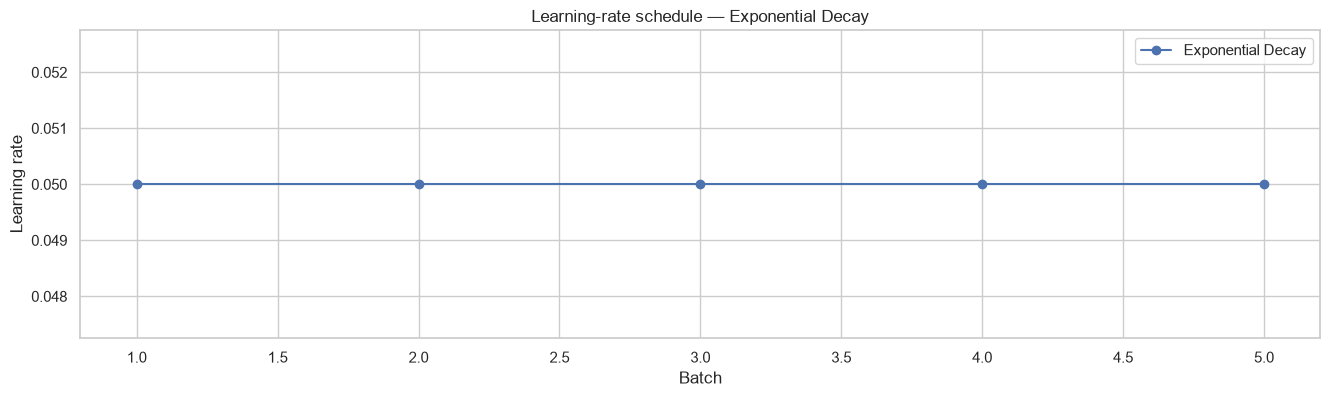

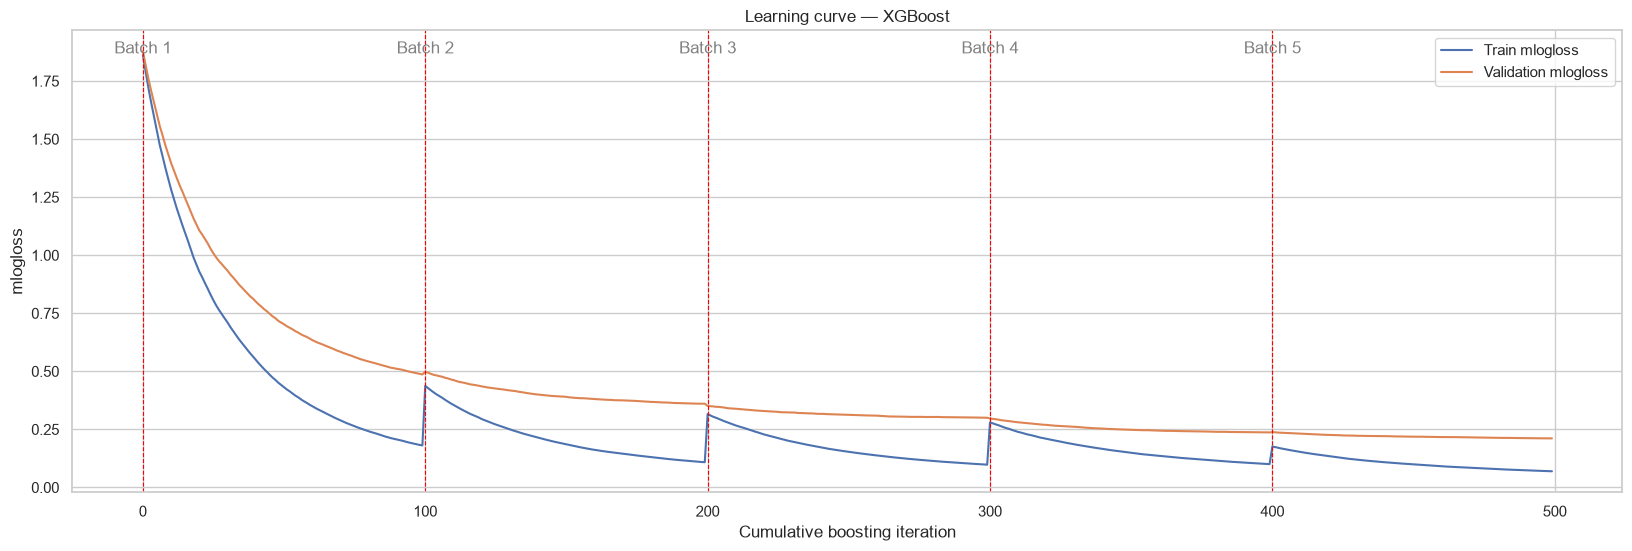

,batch,train_metric,validation_metric
0,1,0.180825,0.486403
1,2,0.108513,0.360509
2,3,0.097784,0.299974
3,4,0.100174,0.236856
4,5,0.069461,0.211101


In [31]:
print("Importing XGBoostTrainer...")
xgboost_trainer = XGBoostTrainer()
print("XGBoostTrainer instantiated successfully")

xgboost_trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_validation_df,
    target_column=TARGET_COLUMN,
    model_config={
        "objective": "multi:softprob",
        "num_class": NUMBER_OF_CLASSES,
        "eval_metric": "mlogloss",
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 6,
        "reg_lambda": 3.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": RANDOM_STATE,
    },
    training_config={
        **TRAINING_CONFIG,
        "max_patience": 2,
        "use_sample_weight": True,
        "show_learning_curve": True,
    },
    learning_rate_config=LEARNING_RATE_CONFIG,
)
xgboost_model = xgboost_trainer.get_trained_model()
display(summarize_history(xgboost_trainer))


########################## STARTING MODEL EVALUATION ###########################

[EVAL] Generating predictions on validation and test datasets...
[EVAL] Plotting comparative multiclass confusion matrices...


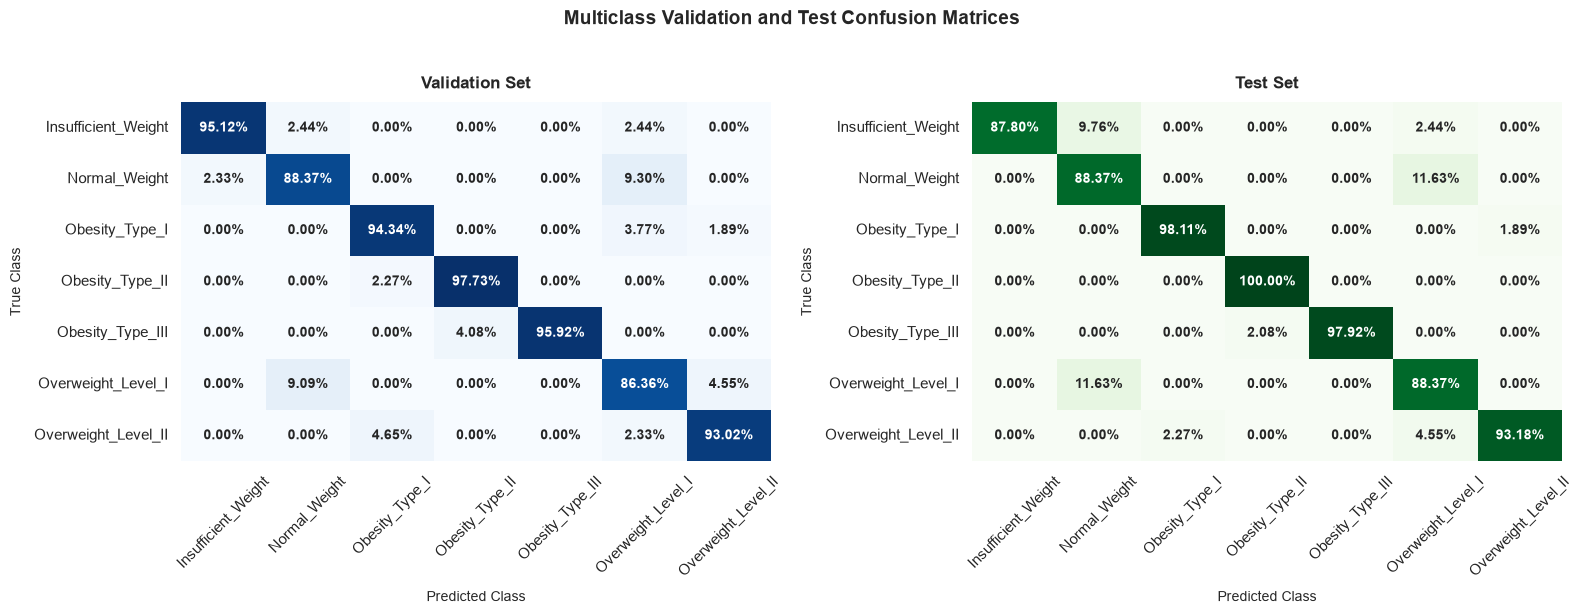


--------------------------------------------------------------------------------
-------------------------- MODEL EVALUATION COMPLETED --------------------------
--------------------------------------------------------------------------------



In [32]:
# ==============================================================================
# 1. MODEL EXTRACTION
# ==============================================================================
print("\n" + "="*80)
print(" STARTING MODEL EVALUATION ".center(80, "#"))
print("="*80 + "\n")

# Retrieve the fully trained XGBoost pipeline artifact
final_model = xgboost_trainer.get_trained_model()

# ==============================================================================
# 2. MULTICLASS PREDICTIONS
# ==============================================================================
print("[EVAL] Generating predictions on validation and test datasets...")
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# ==============================================================================
# 3. VISUALIZATION (MULTICLASS CONFUSION MATRICES)
# ==============================================================================
print("[EVAL] Plotting comparative multiclass confusion matrices...")
plot_multiclass_confusion_matrices(
    y_true_valid=y_valid,
    y_pred_valid=y_pred_valid,
    y_true_test=y_test,
    y_pred_test=y_pred_test,
    mapping_df=mapping,  # Dynamically maps and sorts class IDs and names
    normalize=True       # Normalizes values to display percentages (%)
)

print("\n" + "-"*80)
print(" MODEL EVALUATION COMPLETED ".center(80, "-"))
print("-"*80 + "\n")

## Phase 7 — Train CatBoost

CatBoost uses its native multiclass objective. File output is disabled to keep notebook runs free of generated training directories.

Importing CatBoostTrainer...
CatBoostTrainer instantiated successfully


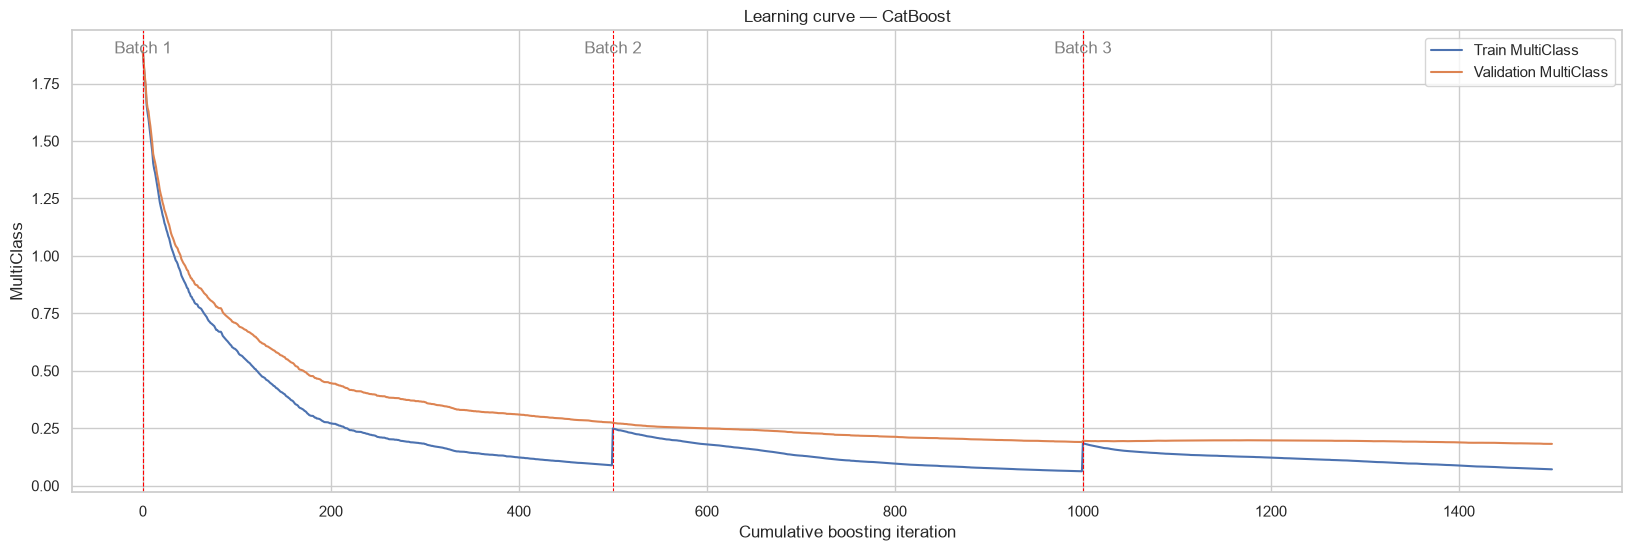

,batch,train_metric,validation_metric
0,1,0.088803,0.274965
1,2,0.062765,0.190182
2,3,0.071257,0.181991


In [33]:
print("Importing CatBoostTrainer...")
catboost_trainer = CatBoostTrainer()
print("CatBoostTrainer instantiated successfully")

catboost_trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_validation_df,
    target_column=TARGET_COLUMN,
    model_config={
        "loss_function": "MultiClass",
        "eval_metric": "MultiClass",
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "l2_leaf_reg": 3.0,
        "auto_class_weights": "Balanced",
        "bootstrap_type": "Bernoulli",
        "subsample": 0.8,
        "random_seed": RANDOM_STATE,
        "verbose": False,
    },
    training_config={
        **TRAINING_CONFIG,
        "num_batches": 3,
        "max_patience": 2,
        "show_learning_curve": True,
    },
)
catboost_model = catboost_trainer.get_trained_model()
display(summarize_history(catboost_trainer))


########################## STARTING MODEL EVALUATION ###########################

[EVAL] Generating predictions on validation and test datasets...
[EVAL] Plotting comparative multiclass confusion matrices...


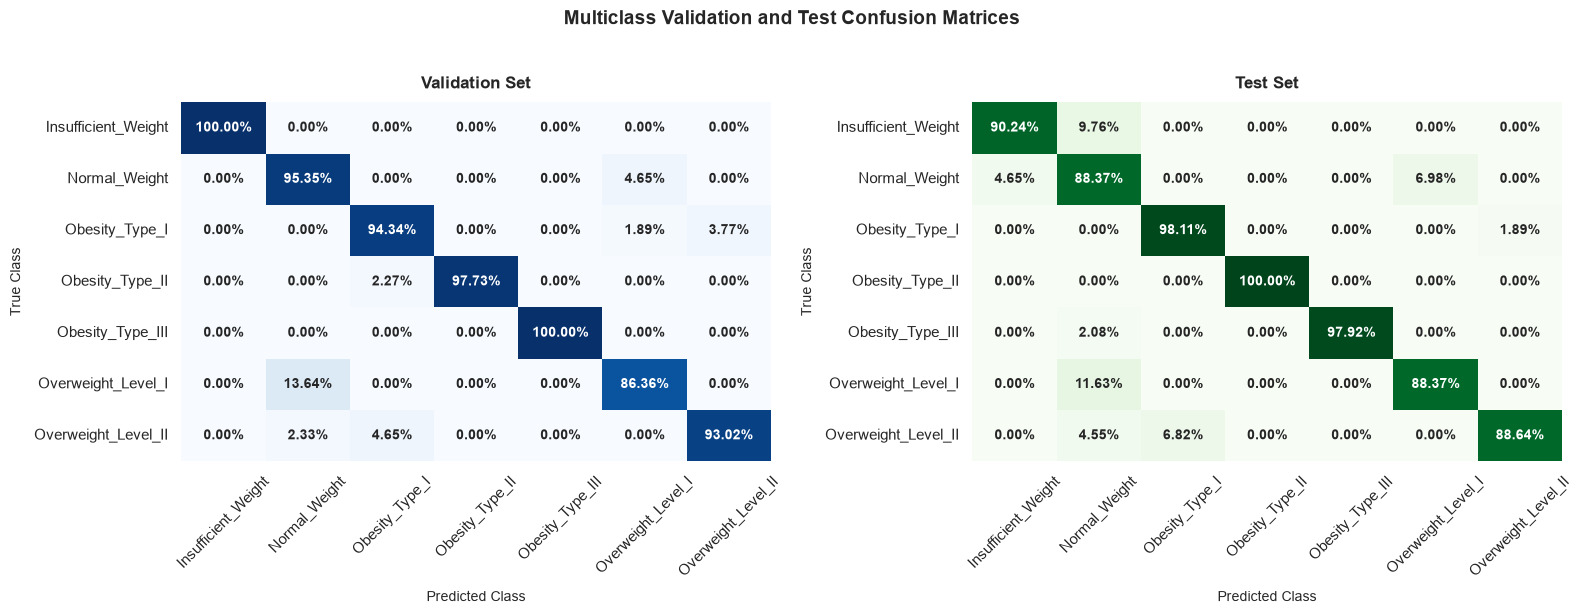


--------------------------------------------------------------------------------
-------------------------- MODEL EVALUATION COMPLETED --------------------------
--------------------------------------------------------------------------------



In [ ]:
# ==============================================================================
# 1. MODEL EXTRACTION
# ==============================================================================
print("\n" + "="*80)
print(" STARTING MODEL EVALUATION ".center(80, "#"))
print("="*80 + "\n")

# Retrieve the fully trained CatBoost pipeline artifact
final_model = catboost_trainer.get_trained_model()

# ==============================================================================
# 2. MULTICLASS PREDICTIONS
# ==============================================================================
print("[EVAL] Generating predictions on validation and test datasets...")
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# ==============================================================================
# 3. VISUALIZATION (MULTICLASS CONFUSION MATRICES)
# ==============================================================================
print("[EVAL] Plotting comparative multiclass confusion matrices...")
plot_multiclass_confusion_matrices(
    y_true_valid=y_valid,
    y_pred_valid=y_pred_valid,
    y_true_test=y_test,
    y_pred_test=y_pred_test,
    mapping_df=mapping,  # Dynamically maps and sorts class IDs and names
    normalize=True       # Normalizes values to display percentages (%)
)

print("\n" + "-"*80)
print(" MODEL EVALUATION COMPLETED ".center(80, "-"))
print("-"*80 + "\n")

## Phase 8 — Train LightGBM

LightGBM requires both the multiclass objective and the number of encoded classes.

Importing LightGBMTrainer...
LightGBMTrainer instantiated successfully


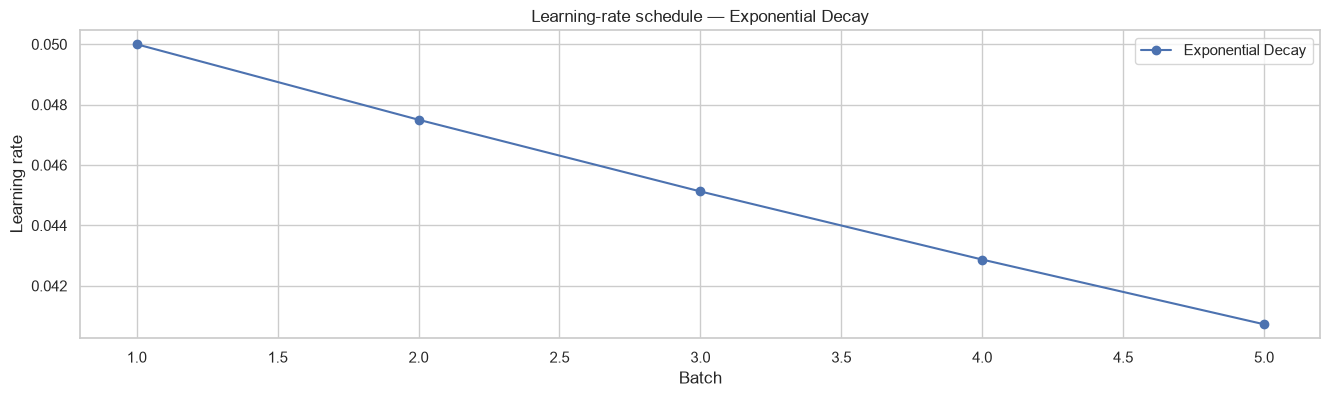

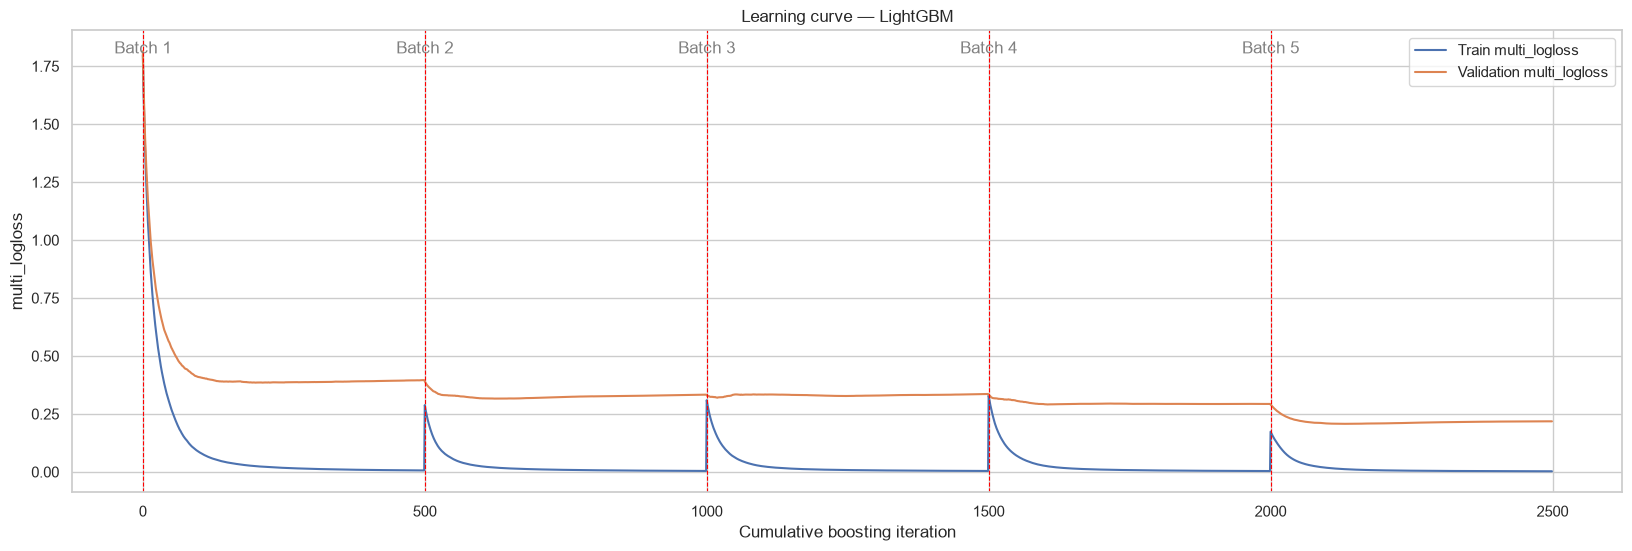

,batch,train_metric,validation_metric
0,1,0.006318,0.395817
1,2,0.004142,0.333194
2,3,0.004086,0.336102
3,4,0.003731,0.293118
4,5,0.002724,0.218121


In [ ]:
print("Importing LightGBMTrainer...")
lightgbm_trainer = LightGBMTrainer()
print("LightGBMTrainer instantiated successfully")

lightgbm_trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_validation_df,
    target_column=TARGET_COLUMN,
    model_config={
        "objective": "multiclass",
        "num_class": NUMBER_OF_CLASSES,
        "metric": "multi_logloss",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "reg_lambda": 1.0,
        "force_col_wise": True,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": RANDOM_STATE,
        "verbosity": -1,
    },
    training_config={
        **TRAINING_CONFIG,
        "max_patience": 2,
        "use_sample_weight": True,
        "show_learning_curve": True,
    },
    learning_rate_config=LEARNING_RATE_CONFIG,
)
lightgbm_model = lightgbm_trainer.get_trained_model()
display(summarize_history(lightgbm_trainer))


########################## STARTING MODEL EVALUATION ###########################

[EVAL] Generating predictions on validation and test datasets...
[EVAL] Plotting comparative multiclass confusion matrices...


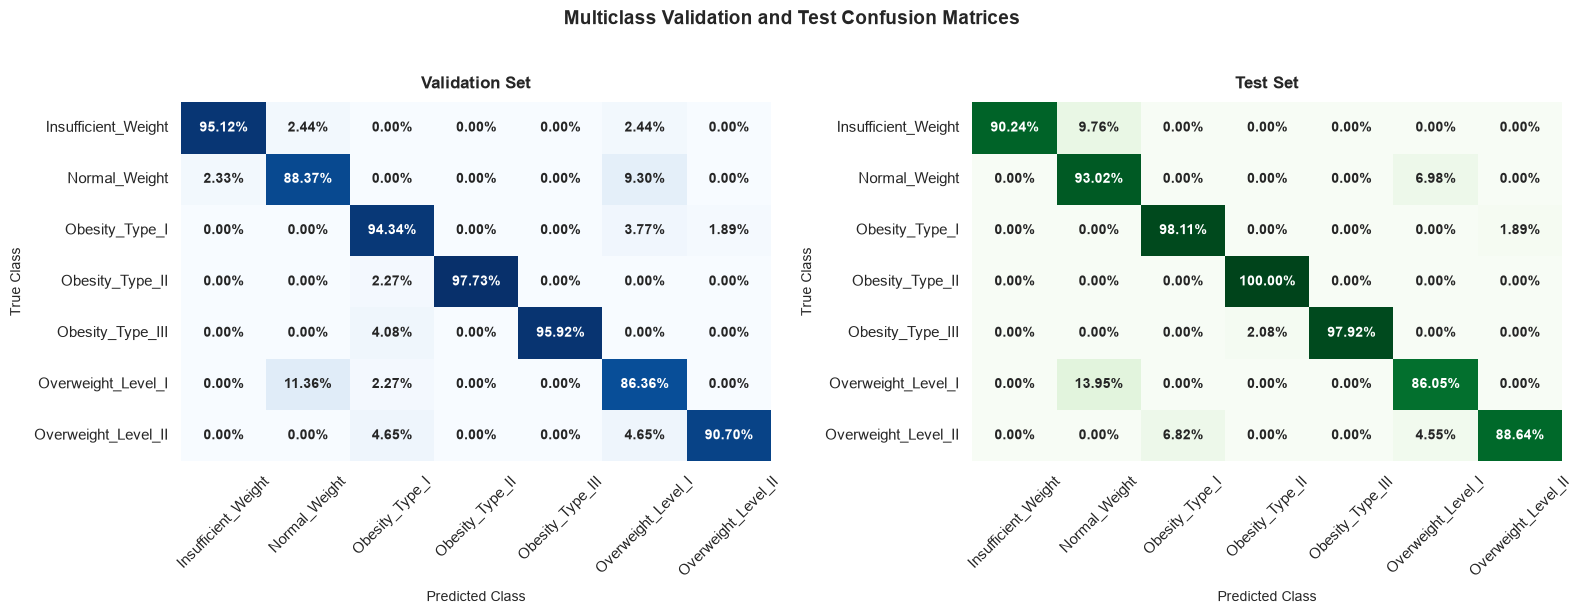


--------------------------------------------------------------------------------
-------------------------- MODEL EVALUATION COMPLETED --------------------------
--------------------------------------------------------------------------------



In [ ]:
# ==============================================================================
# 1. MODEL EXTRACTION
# ==============================================================================
print("\n" + "="*80)
print(" STARTING MODEL EVALUATION ".center(80, "#"))
print("="*80 + "\n")

# Retrieve the fully trained LightGBM pipeline artifact
final_model = lightgbm_trainer.get_trained_model()

# ==============================================================================
# 2. MULTICLASS PREDICTIONS
# ==============================================================================
print("[EVAL] Generating predictions on validation and test datasets...")
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# ==============================================================================
# 3. VISUALIZATION (MULTICLASS CONFUSION MATRICES)
# ==============================================================================
print("[EVAL] Plotting comparative multiclass confusion matrices...")
plot_multiclass_confusion_matrices(
    y_true_valid=y_valid,
    y_pred_valid=y_pred_valid,
    y_true_test=y_test,
    y_pred_test=y_pred_test,
    mapping_df=mapping,  # Dynamically maps and sorts class IDs and names
    normalize=True       # Normalizes values to display percentages (%)
)

print("\n" + "-"*80)
print(" MODEL EVALUATION COMPLETED ".center(80, "-"))
print("-"*80 + "\n")

## Phase 9 — Final Multiclass Model Comparison

The test set is used here to perform the final model evaluation. To streamline the process, we use the unified `evaluate_multiclass_models` function to evaluate our three trained champions (**XGBoost**, **CatBoost**, and **LightGBM**) side-by-side on both the validation and test datasets.

For each model, this pipeline will:
1. **Generate multiclass predictions** on top of validation and test datasets.
2. **Dynamically map and sort** class IDs and human-readable names using our reference mapping DataFrame.
3. **Plot comparative confusion matrices** normalized to percentages (%) to visually assess recall and misclassifications across all target classes.

```python
# Group your trained pipelines into a dictionary
trained_pipelines = {
    "XGBoost": xgboost_trainer.get_trained_model(),
    "CatBoost": catboost_trainer.get_trained_model(),
    "LightGBM": lightgbm_trainer.get_trained_model()
}

# Run the unified multiclass evaluation pipeline
evaluate_multiclass_models(
    models_dict=trained_pipelines,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test,
    mapping_df=mapping
)

In [ ]:
def evaluate_multiclass_models(models_dict, X_valid, y_valid, X_test, y_test, mapping_df):
    """
    Loops through trained models, generates multi-class predictions, 
    and plots comparative confusion matrices using a dynamic class mapping.
    """
    for model_name, model_obj in models_dict.items():
        print("\n" + "="*80)
        print(f" STARTING EVALUATION FOR: {model_name.upper()} ".center(80, "#"))
        print("="*80)
        
        # 1. MODEL PREDICTIONS
        print(f"[{model_name.upper()}] Step 1: Generating multi-class predictions on Validation and Test sets...")
        y_pred_valid = model_obj.predict(X_valid)
        y_pred_test  = model_obj.predict(X_test)
        
        # 2. VISUALIZATION (MULTICLASS CONFUSION MATRICES)
        print(f"[{model_name.upper()}] Step 2: Plotting comparative multiclass confusion matrices...")
        plot_multiclass_confusion_matrices(
            y_true_valid=y_valid,
            y_pred_valid=y_pred_valid,
            y_true_test=y_test,
            y_pred_test=y_pred_test,
            mapping_df=mapping_df,  # Dynamically maps and sorts class IDs and names
            normalize=True          # Normalizes values to display percentages (%)
        )
        
        print(f" {'FINISHED ' + model_name.upper() + ' EVALUATION'} ".center(80, "-"))
        print("\n")


####################### STARTING EVALUATION FOR: XGBOOST #######################
[XGBOOST] Step 1: Generating multi-class predictions on Validation and Test sets...
[XGBOOST] Step 2: Plotting comparative multiclass confusion matrices...


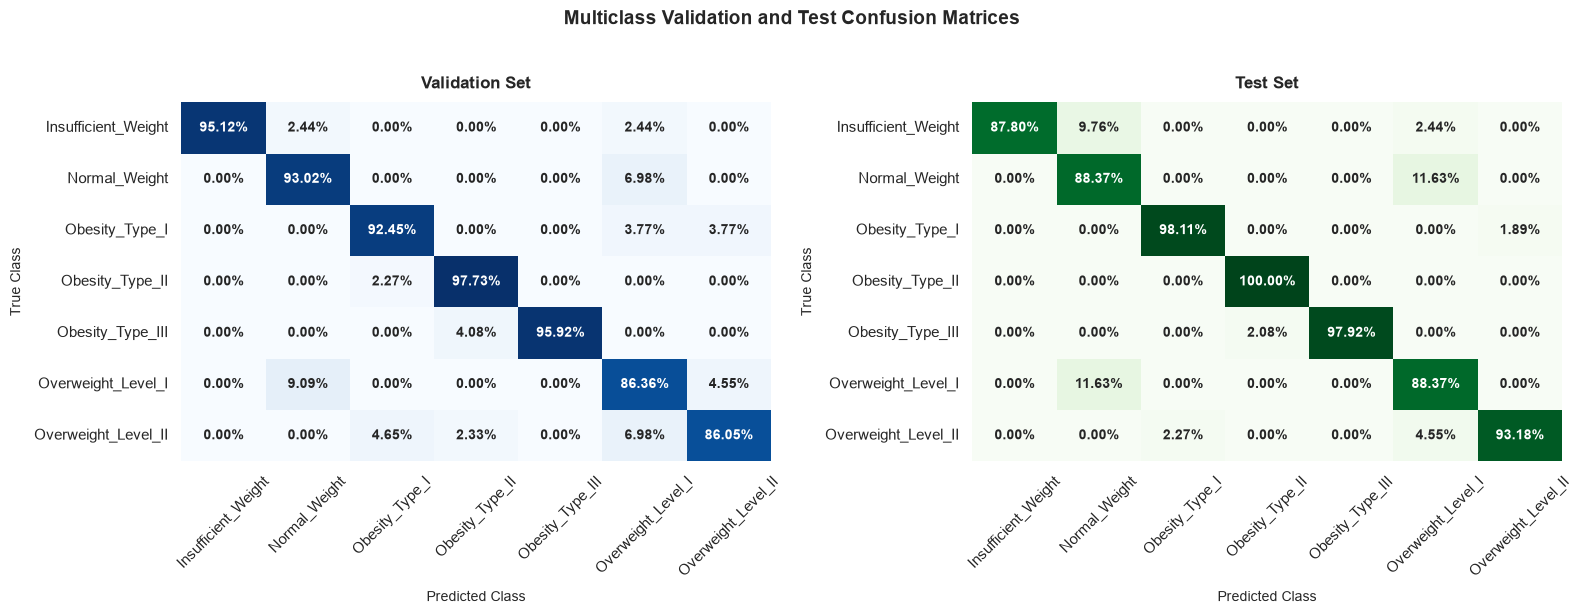

------------------------- FINISHED XGBOOST EVALUATION --------------------------



###################### STARTING EVALUATION FOR: CATBOOST #######################
[CATBOOST] Step 1: Generating multi-class predictions on Validation and Test sets...
[CATBOOST] Step 2: Plotting comparative multiclass confusion matrices...


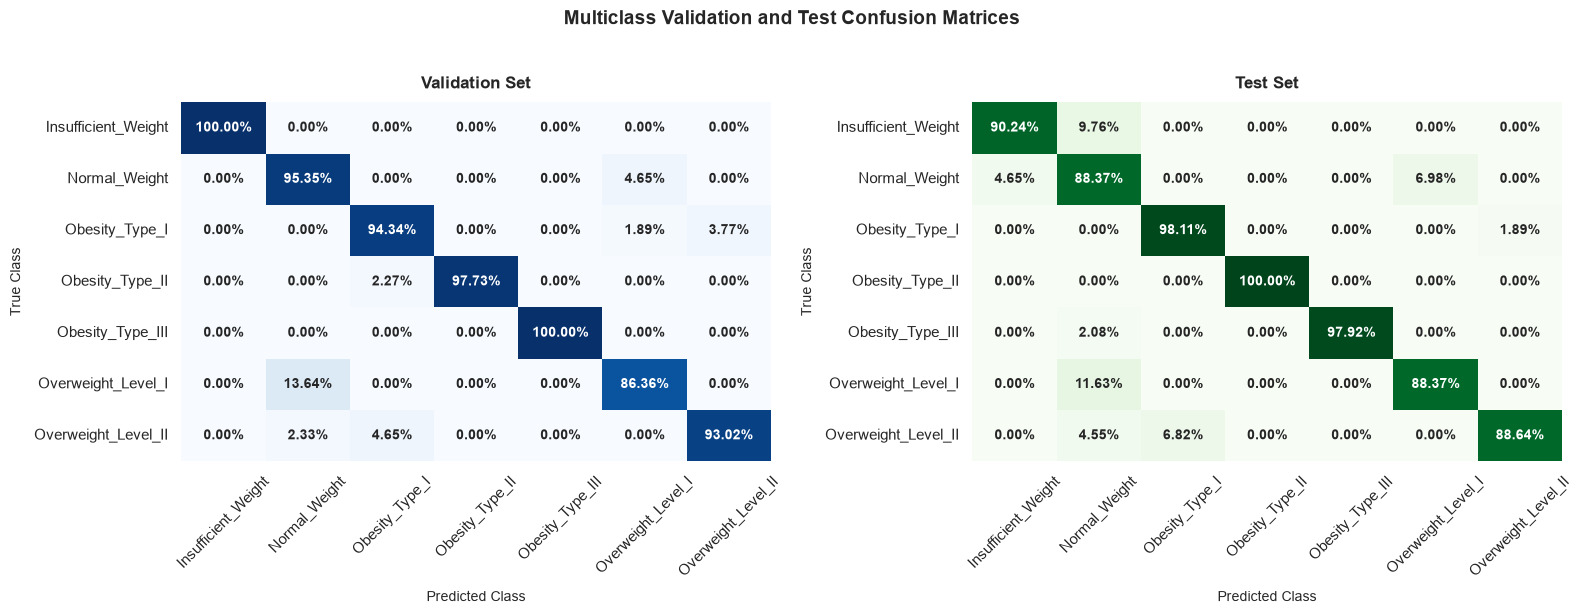

------------------------- FINISHED CATBOOST EVALUATION -------------------------



###################### STARTING EVALUATION FOR: LIGHTGBM #######################
[LIGHTGBM] Step 1: Generating multi-class predictions on Validation and Test sets...
[LIGHTGBM] Step 2: Plotting comparative multiclass confusion matrices...


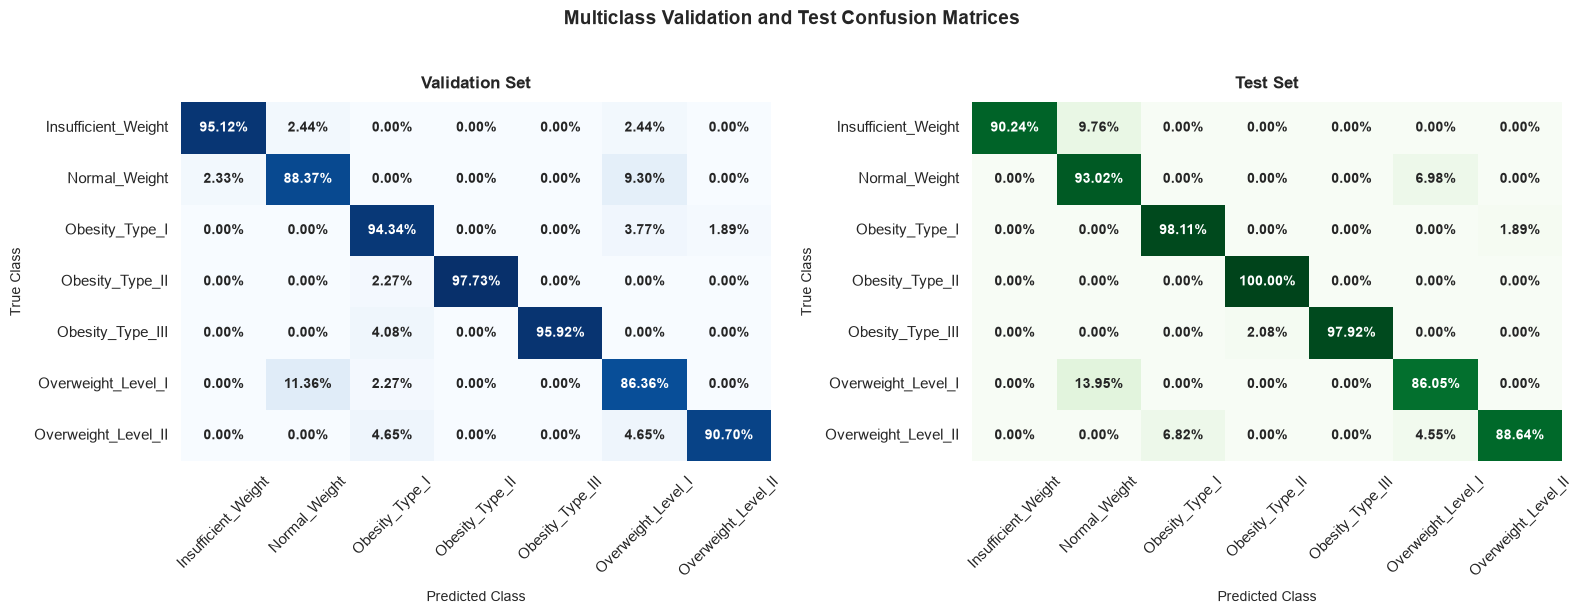

------------------------- FINISHED LIGHTGBM EVALUATION -------------------------




In [ ]:
# ==============================================================================
# MULTICLASS MODELS EVALUATION PIPELINE
# ==============================================================================

# Group your trained pipelines into a dictionary
trained_pipelines = {
    "XGBoost": xgboost_trainer.get_trained_model(),
    "CatBoost": catboost_trainer.get_trained_model(),
    "LightGBM": lightgbm_trainer.get_trained_model()
}

# Run the unified multiclass evaluation pipeline
evaluate_multiclass_models(
    models_dict=trained_pipelines,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test,
    mapping_df=mapping
)

## Phase 10 — Resource cleanup

In [ ]:
spark.stop()